Imports

In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
import numpy as np

### Parte 1: Preparação dos Circuitos Quanticos

### 1.1 Crie um circuito quântico de dois qubits (q0 e q1) que seja capaz de gerar o estado de Bell |ψ−⟩. Esse circuito servirá de base para construção dos 4 circuitos quânticos queserão utilizados em seguida:

In [3]:
def create_circ():
    circ = QuantumCircuit(2)
    circ.x(1) #Pauli_X
    circ.h(0) #hadamard

    circ.cx(0, 1) #cnot

    circ.z(0) #Pauli_Z

    return circ

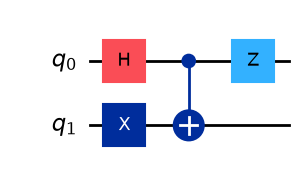

In [4]:
dummy = create_circ()
dummy.draw("mpl")

### 1.2 e 1.3 - Cálculo dos operadores unitários e construção dos circuitos de medida

Para realizar as medidas projetivas associadas aos observáveis \(A_1\), \(A_2\), \(B_1\) e \(B_2\), é necessário aplicar transformações unitárias que convertam a base de cada observável na base computacional, correspondente à medição segundo o operador \(Z\).


**A1B1** - Por \(A_1\) utilizar o Pauli \(Z\), não é necessário mudar a base, então aplica-se a identidade. Já \(B_1\), por utilizar $B_1 = \frac{1}{\sqrt{2}}(-Z-X)$, deve-se realizar uma rotação no eixo \(y\) de $\frac{3\pi}{4}$, utilizando o operador $R_y\left(\frac{3\pi}{4}\right)$.

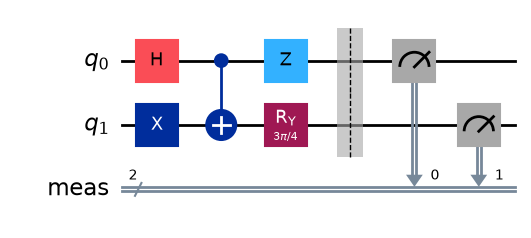

In [5]:
A1B1 = create_circ()

#Para A1 aplica-se identidade
A1B1.ry(3 * np.pi / 4, 1)

A1B1.measure_all()

A1B1.draw("mpl")


**A1B2** - Como \(A_1\) utiliza o operador de Pauli \(Z\), não é necessário realizar uma mudança de base, sendo aplicada a identidade \(I\). Para $B_2 = \frac{1}{\sqrt{2}}(Z-X)$, deve-se realizar uma rotação em torno do eixo \(y\) de $\frac{\pi}{4}$, utilizando o operador $R_y\left(\frac{\pi}{4}\right)$.

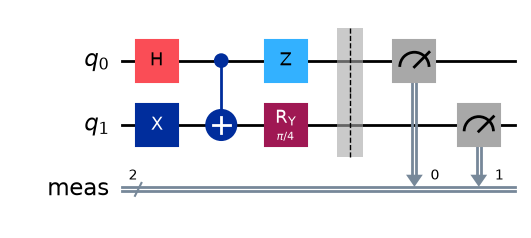

In [6]:
A1B2 = create_circ()

#Para A1 aplica-se identidade
A1B2.ry(np.pi / 4, 1)

A1B2.measure_all()

A1B2.draw("mpl")

**A2B1** - Como \(A_2\) utiliza o operador de Pauli \(X\), aplica-se a porta Hadamard \(H\) para realizar a mudança para a base de medição computacional. Para $B_1 = \frac{1}{\sqrt{2}}(-Z-X)$, deve-se realizar uma rotação em torno do eixo (y\) de $\frac{3\pi}{4}$, utilizando o operador $R_y\left(\frac{3\pi}{4}\right)$.

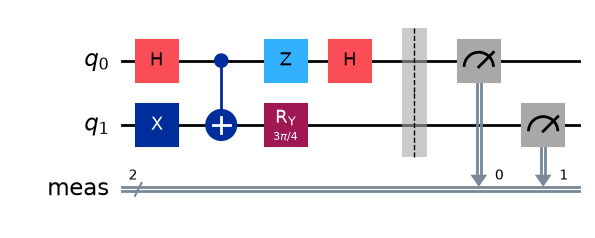

In [7]:
A2B1 = create_circ()

A2B1.h(0)
A2B1.ry(3 * np.pi / 4, 1)

A2B1.measure_all()

A2B1.draw("mpl")

**A2B2** - Como \(A_2\) utiliza o operador de Pauli \(X\), aplica-se a porta Hadamard \(H\) para realizar a mudança para a base de medição computacional. Para $B_2 = \frac{1}{\sqrt{2}}(Z-X)$, deve-se realizar uma rotação em torno do eixo \(y\) de $\frac{\pi}{4}$, utilizando o operador $R_y\left(\frac{\pi}{4}\right)$.

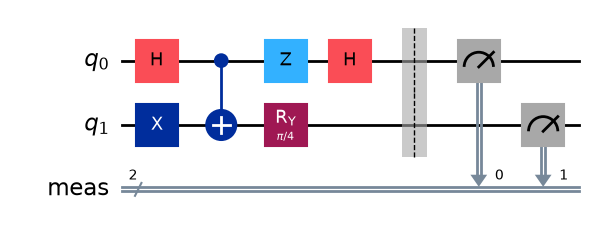

In [8]:
A2B2 = create_circ()

A2B2.h(0)
A2B2.ry(np.pi / 4, 1)

A2B2.measure_all()

A2B2.draw("mpl")

### 2.1 Utilizando o simulador do Qiskit, realize 10000 medidas em cada circuito. Para cada resultado obtido, obtenha o valor médio $\langle A_iB_j \rangle$. (Dica: observe que o Qiskit trata os resultados das medidas como $0$ e $1$, enquanto os observáveis definidos acima possuem resultados possíveis $+1$ e $-1$; não esqueça de levar isso em consideração.)

In [9]:
sim = AerSimulator()

circs = [A1B1, A1B2, A2B1, A2B2]

SEED = 67

circs_transpile = transpile(circs, sim, seed_transpiler=SEED)

res = sim.run(circs_transpile, shots=10000, seed_simulator=SEED).result()

In [10]:
def calc_mean(res, index):
    counts = res.get_counts(index)
    total = sum(counts.values())

    val = 0

    for i in counts:
        if i == "00" or i == "11":
            val += counts[i]
        else:
            val -= counts[i]
    
    return (val) / total

In [11]:
mean_A1B1 = calc_mean(res, 0)
mean_A1B2 = calc_mean(res, 1)
mean_A2B1 = calc_mean(res, 2)
mean_A2B2 = calc_mean(res, 3)
print(mean_A1B1, mean_A1B2, mean_A2B1, mean_A2B2)
print(1/np.sqrt(2)) #Pode-se ver que o módulod e cada observável é próximo de 1/raiz 2, bom sinal para S

0.7054 -0.7096 0.7136 0.7062
0.7071067811865475


In [12]:
print(res.get_counts(0))
print(res.get_counts(1))
print(res.get_counts(2))
print(res.get_counts(3))

{'11': 4314, '00': 4213, '10': 750, '01': 723}
{'10': 4171, '01': 4377, '00': 748, '11': 704}
{'00': 4289, '10': 707, '11': 4279, '01': 725}
{'00': 4341, '11': 4190, '01': 714, '10': 755}


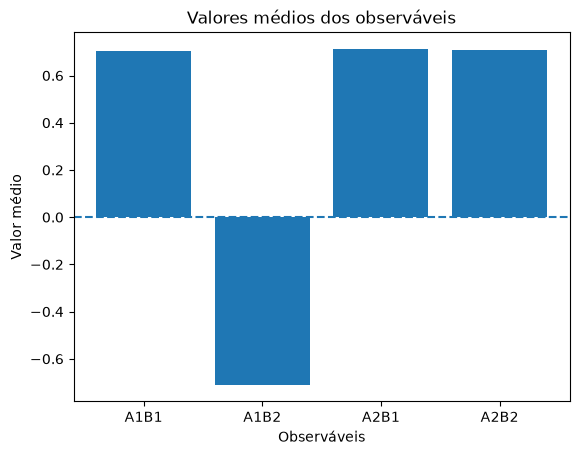

In [13]:
means = [mean_A1B1, mean_A1B2, mean_A2B1, mean_A2B2]
labels = ["A1B1", "A1B2", "A2B1", "A2B2"]

plt.bar(labels, means)

plt.axhline(0, linestyle="--")

plt.xlabel("Observáveis")
plt.ylabel("Valor médio")
plt.title("Valores médios dos observáveis")

plt.show()

### 2.2 Calcule o valor de $S$ e verifique que ele é próximo do valor teórico $2\sqrt{2}$.

In [14]:
S = mean_A1B1 - mean_A1B2 + mean_A2B1 + mean_A2B2

S_teorico = 2 * np.sqrt(2)
diferenca_percentual = abs(S - S_teorico) / S_teorico * 100

print(f"S obtido: {S:.4f}")
print(f"Valor teórico: {S_teorico:.4f}")
print(f"Diferença percentual: {diferenca_percentual:.4f}%")

S obtido: 2.8348
Valor teórico: 2.8284
Diferença percentual: 0.2253%


### Parte 3: Estados Separáveis 
Considere agora, que a espiã, Eva, tomou conta da fonte de estados emaranhados e passa a enviar estados separáveis para Alice e Bob. Ou seja, Eva envia os estados $|01\rangle$ e $|10\rangle$ aleatoriamente, com probabilidades iguais (50%).

### 3.1 Modifique os circuitos quânticos do item 1 de modo a refletir essa estratégia.

In [15]:
def create_eva(state):
    circ = QuantumCircuit(2)

    if state == "01":
        circ.x(0)

    elif state == "10":
        circ.x(1)

    return circ

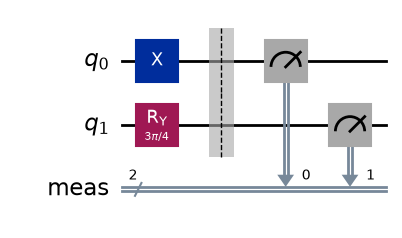

In [16]:
A1B1_01 = create_eva("01")

A1B1_01.ry(3 * np.pi / 4, 1)

A1B1_01.measure_all()

A1B1_01.draw("mpl")


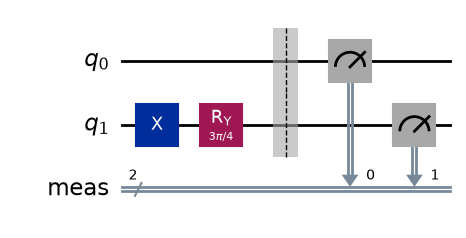

In [17]:
A1B1_10 = create_eva("10")

A1B1_10.ry(3 * np.pi / 4, 1)

A1B1_10.measure_all()

A1B1_10.draw("mpl")

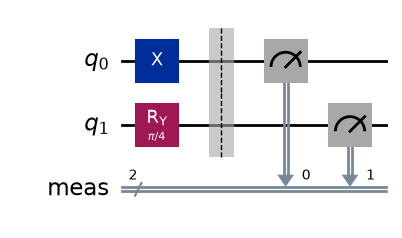

In [18]:
A1B2_01 = create_eva("01")

#Para A1 aplica-se identidade
A1B2_01.ry(np.pi / 4, 1)

A1B2_01.measure_all()

A1B2_01.draw("mpl")

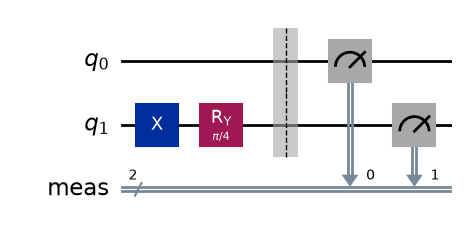

In [19]:
A1B2_10 = create_eva("10")

#Para A1 aplica-se identidade
A1B2_10.ry(np.pi / 4, 1)

A1B2_10.measure_all()

A1B2_10.draw("mpl")

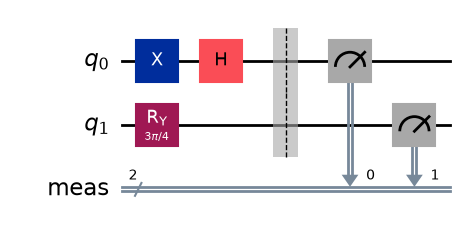

In [20]:
A2B1_01 = create_eva("01")

A2B1_01.h(0)
A2B1_01.ry(3 * np.pi / 4, 1)

A2B1_01.measure_all()

A2B1_01.draw("mpl")

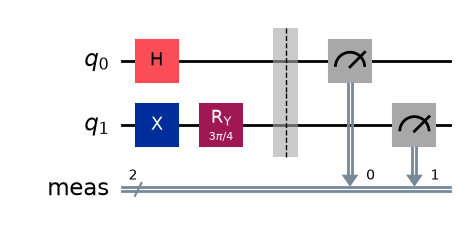

In [21]:
A2B1_10 = create_eva("10")

A2B1_10.h(0)
A2B1_10.ry(3 * np.pi / 4, 1)

A2B1_10.measure_all()

A2B1_10.draw("mpl")

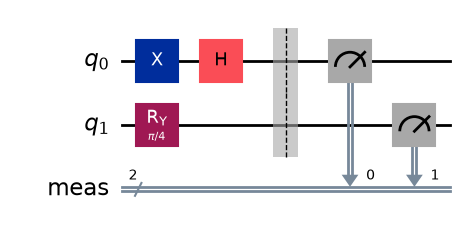

In [22]:
A2B2_01 = create_eva("01")

A2B2_01.h(0)
A2B2_01.ry(np.pi / 4, 1)

A2B2_01.measure_all()

A2B2_01.draw("mpl")

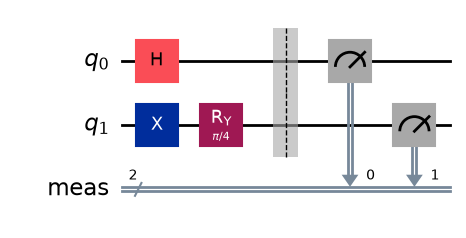

In [23]:
A2B2_10 = create_eva("10")

A2B2_10.h(0)
A2B2_10.ry(np.pi / 4, 1)

A2B2_10.measure_all()

A2B2_10.draw("mpl")

### 3.2 Realize um número suficientemente grande de medidas e calcule o novo valor de $S$. O que você observa?

In [24]:
sim_eva = AerSimulator()


circs_eva = [A1B1_01, A1B1_10, A1B2_01, A1B2_10, A2B1_01, A2B1_10, A2B2_01, A2B2_10]

circs_eva_transpile = transpile(circs_eva, sim_eva, seed_transpiler=SEED)

res_eva = sim_eva.run(circs_eva_transpile, shots=100000, seed_simulator=SEED).result()

In [25]:
mean_A1B1_01 = calc_mean(res_eva, 0)
mean_A1B1_10 = calc_mean(res_eva, 1)

mean_A1B2_01 = calc_mean(res_eva, 2)
mean_A1B2_10 = calc_mean(res_eva, 3)

mean_A2B1_01 = calc_mean(res_eva, 4)
mean_A2B1_10 = calc_mean(res_eva, 5)

mean_A2B2_01 = calc_mean(res_eva, 6)
mean_A2B2_10 = calc_mean(res_eva, 7)

In [26]:
print(res_eva.get_counts(0))
print(res_eva.get_counts(1))
print(res_eva.get_counts(2))
print(res_eva.get_counts(3))
print(res_eva.get_counts(4))
print(res_eva.get_counts(5))
print(res_eva.get_counts(6))
print(res_eva.get_counts(7))

{'11': 85540, '01': 14460}
{'10': 14832, '00': 85168}
{'01': 85477, '11': 14523}
{'10': 85180, '00': 14820}
{'00': 7241, '11': 42985, '10': 42420, '01': 7354}
{'01': 42613, '10': 7234, '00': 42739, '11': 7414}
{'00': 42787, '01': 42775, '10': 7170, '11': 7268}
{'00': 7295, '10': 42686, '11': 42674, '01': 7345}


In [27]:
mean_A1B1_eva = (mean_A1B1_01 + mean_A1B1_10) / 2
mean_A1B2_eva = (mean_A1B2_01 + mean_A1B2_10) / 2
mean_A2B1_eva = (mean_A2B1_01 + mean_A2B1_10) / 2
mean_A2B2_eva = (mean_A2B2_01 + mean_A2B2_10) / 2

print(mean_A1B1_eva, mean_A1B2_eva, mean_A2B1_eva, mean_A2B2_eva)

0.7070799999999999 -0.7065699999999999 0.00379 0.00024000000000000003


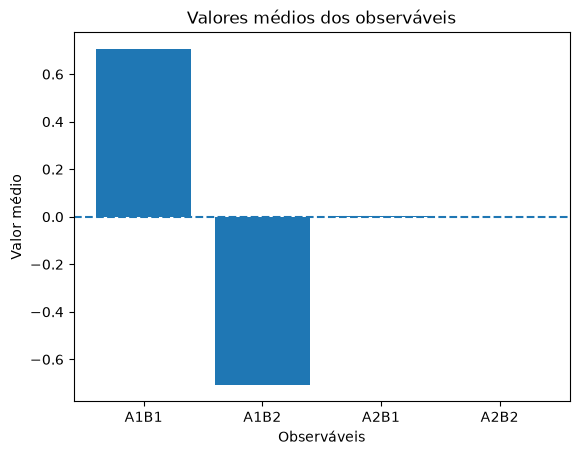

In [28]:
means = [mean_A1B1_eva, mean_A1B2_eva, mean_A2B1_eva, mean_A2B2_eva]
labels = ["A1B1", "A1B2", "A2B1", "A2B2"]

plt.bar(labels, means)

plt.axhline(0, linestyle="--")

plt.xlabel("Observáveis")
plt.ylabel("Valor médio")
plt.title("Valores médios dos observáveis")

plt.show()

In [29]:
S_eva = mean_A1B1_eva - mean_A1B2_eva + mean_A2B1_eva + mean_A2B2_eva

print(f"<A1B1> = {mean_A1B1_eva:.5f}")
print(f"<A1B2> = {mean_A1B2_eva:.5f}")
print(f"<A2B1> = {mean_A2B1_eva:.5f}")
print(f"<A2B2> = {mean_A2B2_eva:.5f}")
print(f"S obtido com Eva: {S_eva:.5f}")
print(f"Valor esperado para muitos shots: {np.sqrt(2):.5f}")
print("Como |S| < 2, não há violação da desigualdade de Bell-CHSH.")

<A1B1> = 0.70708
<A1B2> = -0.70657
<A2B1> = 0.00379
<A2B2> = 0.00024
S obtido com Eva: 1.41768
Valor esperado para muitos shots: 1.41421
Como |S| < 2, não há violação da desigualdade de Bell-CHSH.
